In [46]:
import streamlit as st
import pandas as pd
import numpy as np
import yfinance as yf
import plotly.graph_objects as go
import plotly.express as px
from datetime import datetime , date
from dateutil.relativedelta import relativedelta
from datetime import timedelta
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
import itertools
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

warnings.filterwarnings('ignore')
%matplotlib inline

In [47]:
df = yf.download('GOOGL' , start = '2025-04-18' , end='2026-04-17')
print(df.head())
print(df.columns)
print(df.index)
print(type(df.index))

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker           GOOGL       GOOGL       GOOGL       GOOGL     GOOGL
Date                                                                
2025-04-21  147.159729  148.435305  145.595162  148.365555  26049100
2025-04-22  150.946594  151.664107  148.026711  148.375508  26971800
2025-04-23  154.813187  156.985646  153.278500  155.072283  31128800
2025-04-24  158.729614  159.038541  155.251668  155.610425  45894000
2025-04-25  161.400360  165.526054  160.483526  164.499614  56034000
MultiIndex([( 'Close', 'GOOGL'),
            (  'High', 'GOOGL'),
            (   'Low', 'GOOGL'),
            (  'Open', 'GOOGL'),
            ('Volume', 'GOOGL')],
           names=['Price', 'Ticker'])
DatetimeIndex(['2025-04-21', '2025-04-22', '2025-04-23', '2025-04-24',
               '2025-04-25', '2025-04-28', '2025-04-29', '2025-04-30',
               '2025-05-01', '2025-05-02',
               ...
               '2026-04-02', '2026-04-06

In [48]:
df.columns = df.columns.get_level_values(0) if isinstance(df.columns , pd.MultiIndex)else df.columns
df.index = pd.to_datetime(df.index)
df = df.sort_index()
df = df.dropna()
df

Price,Close,High,Low,Open,Volume
Date,,,,,
2025-04-21,147.159729,148.435305,145.595162,148.365555,26049100
2025-04-22,150.946594,151.664107,148.026711,148.375508,26971800
2025-04-23,154.813187,156.985646,153.278500,155.072283,31128800
2025-04-24,158.729614,159.038541,155.251668,155.610425,45894000
2025-04-25,161.400360,165.526054,160.483526,164.499614,56034000
...,...,...,...,...,...
2026-04-10,317.239990,321.829987,316.320007,320.019989,19152600
2026-04-13,321.309998,321.630005,315.470001,317.140015,18866400
2026-04-14,332.910004,333.290009,323.750000,324.790009,27721400


In [49]:
from statsmodels.tsa.stattools import adfuller
ts = df['Close'].dropna()
res = adfuller(ts)
print('ADF Statistics' , res[0])    
print('p values' , res[1])
d = 0
while True:
    if(res[1]<=0.05):
        print(f'Stationary achieved' , res[1])
        break 
    d+=1
    ts = df['Close'].diff().dropna()
    res = adfuller(ts)
    print(f'--- Differencing Level: {d} ---')
    print(f'ADF Statistic: {res[0]}')
    print(f'p-value: {res[1]}')
    
# d = 1


ADF Statistics -0.9706312713159453
p values 0.7638246233750252
--- Differencing Level: 1 ---
ADF Statistic: -14.417020418046452
p-value: 8.027633855145083e-27
Stationary achieved 8.027633855145083e-27


In [50]:
ts

Date
2025-04-22     3.786865
2025-04-23     3.866592
2025-04-24     3.916428
2025-04-25     2.670746
2025-04-28    -1.345337
                ...    
2026-04-10    -1.250000
2026-04-13     4.070007
2026-04-14    11.600006
2026-04-15     4.209991
2026-04-16    -1.100006
Name: Close, Length: 248, dtype: float64

In [51]:
ts.values , ts.index 

(array([  3.78686523,   3.86659241,   3.91642761,   2.67074585,
         -1.34533691,  -0.44845581,  -1.35528564,   2.49136353,
          2.72055054,   0.17938232,  -0.97662354, -11.80905151,
          2.88996887,  -1.52468872,   5.6902771 ,   1.06628418,
          5.81980896,  -1.40510559,   2.22227478,   0.34880066,
         -2.55116272,   4.56417847,   2.30201721,  -2.39170837,
          4.41470337,  -0.53813171,  -0.49827576,  -0.11956787,
         -2.70066833,  -2.84014893,   1.86354065,   0.15945435,
          5.45108032,   2.61412048,   2.50436401,  -1.24719238,
         -1.64628601,  -1.0276947 ,   2.09529114,  -0.81817627,
         -2.62405396,  -6.66497803,  -1.44674683,   1.57644653,
          3.90119934,   2.8535614 ,   4.97877502,  -2.29481506,
         -0.38911438,   2.79368591,   0.88800049,  -2.73384094,
         -2.42453003,   2.25492859,   0.99772644,   2.5642395 ,
          1.36691284,   0.43902588,   0.96780396,   0.60864258,
          1.47665405,   5.02867126,   1.

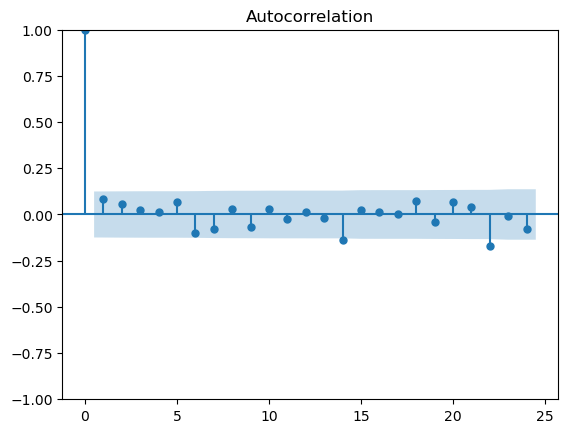

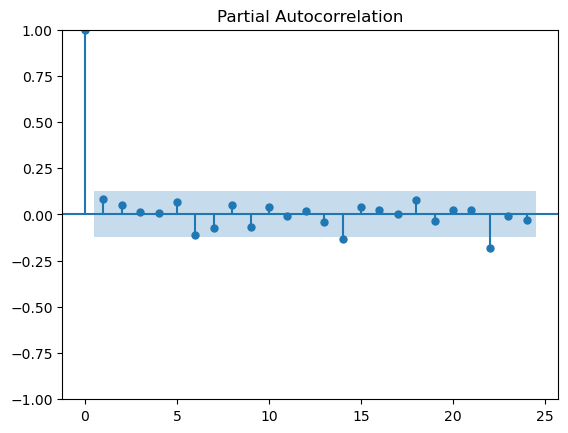

In [52]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
plot_acf(ts)
plt.show()
plot_pacf(ts)
plt.show()

In [53]:

train_size = int(len(ts) * 0.8)
train, test = ts[:train_size], ts[train_size:]
train.index,test.index

(DatetimeIndex(['2025-04-22', '2025-04-23', '2025-04-24', '2025-04-25',
                '2025-04-28', '2025-04-29', '2025-04-30', '2025-05-01',
                '2025-05-02', '2025-05-05',
                ...
                '2026-01-21', '2026-01-22', '2026-01-23', '2026-01-26',
                '2026-01-27', '2026-01-28', '2026-01-29', '2026-01-30',
                '2026-02-02', '2026-02-03'],
               dtype='datetime64[ns]', name='Date', length=198, freq=None),
 DatetimeIndex(['2026-02-04', '2026-02-05', '2026-02-06', '2026-02-09',
                '2026-02-10', '2026-02-11', '2026-02-12', '2026-02-13',
                '2026-02-17', '2026-02-18', '2026-02-19', '2026-02-20',
                '2026-02-23', '2026-02-24', '2026-02-25', '2026-02-26',
                '2026-02-27', '2026-03-02', '2026-03-03', '2026-03-04',
                '2026-03-05', '2026-03-06', '2026-03-09', '2026-03-10',
                '2026-03-11', '2026-03-12', '2026-03-13', '2026-03-16',
                '2026-0

In [60]:
best_rmse = None 
best_order = None
best_rmse = float("inf")
# split data
train_size = int(len(ts) * 0.8)
train, test = ts[:train_size], ts[train_size:]

for p in range(0,5):
    for q in range(0,5):
        model = ARIMA(train, order  = (p,1,q))
        res = model.fit()
        pred = res.forecast(steps=len(test))
        mse = mean_squared_error(test,pred)
        rmse = np.sqrt(mse)
        if(rmse<best_rmse):
            best_order = (p,1,q)
            best_rmse = rmse
            
print( 'Best order is : ', best_order)
print(rmse)

Best order is :  (2, 1, 0)
5.79234534381955


In [61]:
# Rolling ARIMA..

history = list(train)
predictions = []
for i in range(len(test)):
    order = (2,1,0)
    final_model = ARIMA(history , order   = (2,1,0))
    res = final_model.fit()
    final_pred = float(res.forecast()[0]) # 1 step forecast
    predictions.append(final_pred) # append the predictions .
    history.append(float(test.iloc[i])) # append the history .
    
rmse = np.sqrt(mean_squared_error(test,predictions))
print(rmse)

6.2268113038623465


## Base-Line Model

In [56]:
order = (0,1,0)
baseline_model = ARIMA(train , order  = order)
res = baseline_model.fit()
baseline_pred = res.forecast(len(test))
mse = mean_squared_error(test,baseline_pred)
rmse = np.sqrt(mse)
print(rmse)

6.909932073351279


## Plot for ARIMA

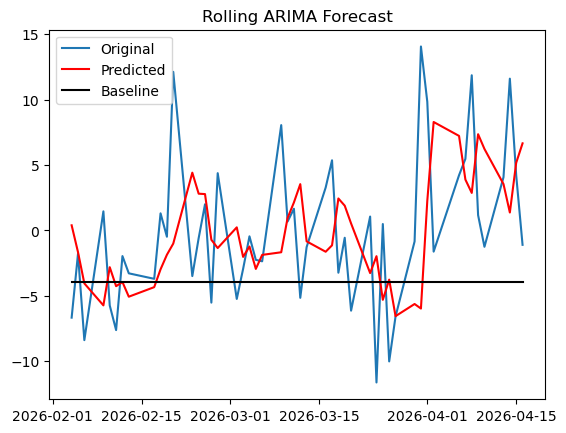

In [57]:
plt.plot(test.index,test, label = 'Original')
plt.plot(test.index,predictions, label = 'Predicted' , color ='red')
plt.plot(test.index,baseline_pred, label = 'Baseline' , color ='black')
plt.legend()
plt.title('Rolling ARIMA Forecast')
plt.show()

In [58]:
test

Date
2026-02-04    -6.665283
2026-02-05    -1.788757
2026-02-06    -8.384094
2026-02-09     1.458984
2026-02-10    -5.735992
2026-02-11    -7.614624
2026-02-12    -1.958618
2026-02-13    -3.277679
2026-02-17    -3.697418
2026-02-18     1.309082
2026-02-19    -0.479645
2026-02-20    12.121460
2026-02-23    -3.487549
2026-02-24    -0.589569
2026-02-25     1.998566
2026-02-26    -5.516083
2026-02-27     4.376923
2026-03-02    -5.236359
2026-03-03    -2.937927
2026-03-04    -0.449646
2026-03-05    -2.248444
2026-03-06    -2.358337
2026-03-09     8.049988
2026-03-10     0.680023
2026-03-11     1.660004
2026-03-12    -5.150024
2026-03-13    -1.269989
2026-03-16     3.279999
2026-03-17     5.360016
2026-03-18    -3.230011
2026-03-19    -0.559998
2026-03-20    -6.130005
2026-03-23     1.059998
2026-03-24   -11.619995
2026-03-25     0.489990
2026-03-26   -10.009979
2026-03-27    -6.580017
2026-03-30    -0.839996
2026-03-31    14.059998
2026-04-01     9.830017
2026-04-02    -1.620026
2026-04-06 

## ARIMA PREDICTION for 30 Days

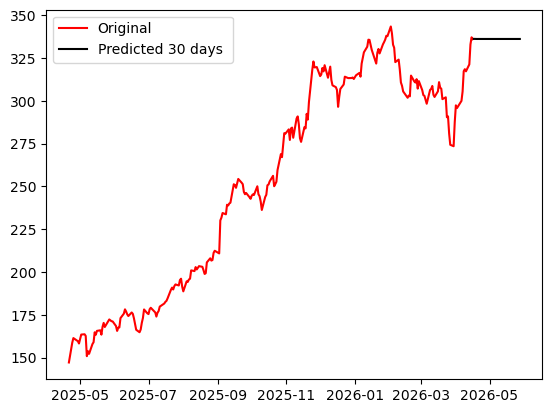

In [63]:
series =  df['Close'].dropna()
# model_30 = ARIMA(series , order = (2,1,0))
# res = model_30.fit()
# forecasst_30 = res.forecast(steps = 30) 
history = list(df['Close'].dropna())
predictions_30 = []

order = (2,1,0)   # or your best_order

for i in range(30):
    model = ARIMA(history, order=order)
    res = model.fit()

    yhat = float(res.forecast()[0])
    predictions_30.append(yhat)

    history.append(yhat)   
future_index = pd.date_range(
    start=series.index[-1],
    periods=31,
    freq='B' 
)[1:]

plt.plot(series.index,series, label = 'Original' , color = 'red')
plt.plot(future_index, predictions_30,  label = 'Predicted 30 days ' , color = 'Black')
plt.legend()
plt.show()  

In [64]:
predictions_30

[336.2070707379226,
 336.1481510583613,
 336.155461111452,
 336.15203381726656,
 336.1522069345406,
 336.1519823402157,
 336.1519720925892,
 336.1519552137277,
 336.1519528018143,
 336.1519513690056,
 336.1519510553987,
 336.15195092287297,
 336.15195088747436,
 336.15195087457647,
 336.15195087078683,
 336.15195086949706,
 336.15195086910046,
 336.1519508689697,
 336.1519508689286,
 336.15195086891526,
 336.151950868911,
 336.15195086890964,
 336.1519508689092,
 336.15195086890907,
 336.151950868909,
 336.151950868909,
 336.151950868909,
 336.151950868909,
 336.151950868909,
 336.151950868909]